In [7]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error


# Advertising Spend vs. Sales Revenue: Data Modeling Project

## Introduction
 
In this project, we explore the relationship between a company's advertising spending and its sales revenue. The goal is to determine whether increased investment in advertising leads to higher sales, using a simple data modeling approach.

This analysis is based on a synthetic dataset representing 24 months of financial data for a fictional company. The dataset includes monthly advertising spend and corresponding sales revenue. We will use Python to perform exploratory data analysis, calculate correlations, and build a simple linear regression model to quantify the relationship between advertising and sales.
 
The project is designed to demonstrate basic data modeling skills using Python and Jupyter Notebook, with a focus on clear analysis, visualization, and interpretation of results.

In [20]:
# Load the dataset
df = pd.read_csv("finance_advertising_sales_data.csv")
 
# Preview the first few rows
df.tail()



,Month,Advertising_Spend,Sales_Revenue
19,20,7.91,90.53
20,21,11.12,109.29
21,22,6.39,82.81
22,23,7.92,89.02
23,24,8.66,91.79


In [7]:
# Basic info about the dataset
df.info()
 
# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              24 non-null     int64  
 1   Advertising_Spend  24 non-null     float64
 2   Sales_Revenue      24 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 708.0 bytes


,Month,Advertising_Spend,Sales_Revenue
count,24.000000,24.000000,24.000000
mean,12.500000,9.401250,96.000417
std,7.071068,2.913701,16.360391
min,1.000000,5.210000,72.150000
25%,6.750000,6.827500,83.215000
50%,12.500000,8.705000,91.345000
75%,18.250000,11.360000,109.027500
max,24.000000,14.700000,132.760000


## Exploratory Data Analysis (EDA)
 
In this section, we will explore the dataset to understand the distribution of advertising spend and sales revenue. We will compute basic statistics, identify trends, and prepare the data for modeling.

In [21]:
# Summary statistics for each column
df.describe()

,Month,Advertising_Spend,Sales_Revenue
count,24.000000,24.000000,24.000000
mean,12.500000,9.401250,96.000417
std,7.071068,2.913701,16.360391
min,1.000000,5.210000,72.150000
25%,6.750000,6.827500,83.215000
50%,12.500000,8.705000,91.345000
75%,18.250000,11.360000,109.027500
max,24.000000,14.700000,132.760000


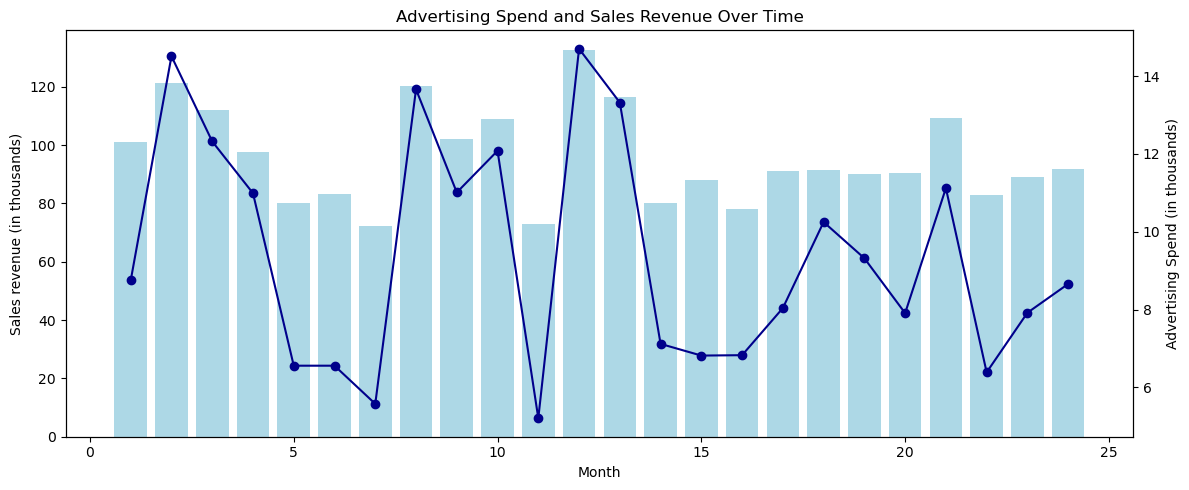

In [25]:
# Plotting Advertising Spend and Sales Revenue over time
fig, ax1 = plt.subplots(figsize=(12, 5))
 
# Sales revenue - Bar on primary y-axes
ax1.bar(df['Month'], df['Sales_Revenue'], label='Sales Revenue', color="lightblue")
ax1.set_xlabel("Month")
ax1.set_ylabel('Sales revenue (in thousands)',color="black")
ax1.tick_params(axis="y", labelcolor="black")
 
# Advertising Spend - Line on secondary y-axes
ax2 = ax1.twinx()
ax2.plot(df['Month'], df['Advertising_Spend'], label='Advertising_Spend', color="darkblue",marker="o" )
ax2.set_ylabel('Advertising Spend (in thousands)',color="black")
ax2.tick_params(axis="y", labelcolor="black")
 
plt.title('Advertising Spend and Sales Revenue Over Time')
plt.grid(False)
fig.tight_layout()
plt.show()

Let's check how strongly advertising and sales are related:

In [26]:
# Calculate correlation between Advertising Spend and Sales Revenue
correlation = df['Advertising_Spend'].corr(df['Sales_Revenue'])
print(f"Correlation between Advertising Spend and Sales Revenue: {correlation:.2f}")

Correlation between Advertising Spend and Sales Revenue: 0.96


As another level of correlation, let's check if there is seasonality:

In [27]:
correlation = df['Month'].corr(df['Sales_Revenue'])
print(f"Correlation between Month and Sales Revenue: {correlation:.2f}")

Correlation between Month and Sales Revenue: -0.25


### Key Insights from EDA
 
- The average advertising spend over 24 months is approximately **9.4** thousand.
- The average sales revenue is approximately **96** thousand.
- The correlation between advertising spend and sales revenue is **0.96**, indicating a strong positive relationship.
- The correlation between Month and Sales Revenu is **-0.25**, indicating a weak realationship.
- The two correlations proove that there is no seasonality and our products are dependent on advertising.
- From the line chart, we observe that sales tend to increase in months with higher advertising spend, suggesting a potential linear relationship.


## Modeling the Relationship (Linear Regression)
 
To understand how advertising spend influences sales revenue, we will build a simple linear regression model. This model will help us quantify the relationship and make predictions based on advertising investment

In [28]:
# Reshape the data for sklearn
X = df[['Advertising_Spend']]  # Independent variable
y = df['Sales_Revenue']        # Dependent variable
 
# Create and fit the model
model = LinearRegression()
model.fit(X, y)
 
# Get the slope (coefficient) and intercept
slope = model.coef_[0]
intercept = model.intercept_
 
print(f"Linear Regression Equation: Sales_Revenue = {intercept:.2f} + {slope:.2f} * Advertising_Spend")

Linear Regression Equation: Sales_Revenue = 45.13 + 5.41 * Advertising_Spend


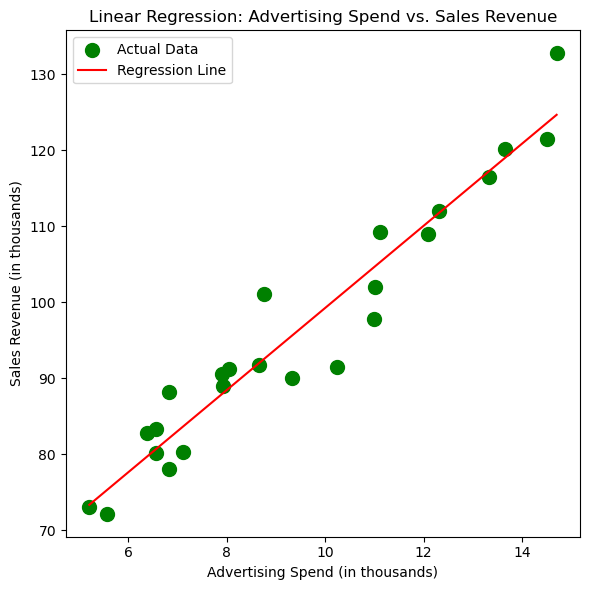

In [29]:
###### Scatter plot of the data
plt.figure(figsize=(6, 6))
plt.scatter(df['Advertising_Spend'], df['Sales_Revenue'], color='green', label='Actual Data',marker="o", s=100)
 
# Regression line
x_vals = np.linspace(df['Advertising_Spend'].min(), df['Advertising_Spend'].max(), 100)
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='red', label='Regression Line')
 
plt.title('Linear Regression: Advertising Spend vs. Sales Revenue')
plt.xlabel('Advertising Spend (in thousands)')
plt.ylabel('Sales Revenue (in thousands)')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

### Interpretation of the Model
 
The linear regression model suggests the following relationship:
 
**Sales_Revenue = 45.13 + 5.41 × Advertising_Spend**
 
This means that for every additional thousand spent on advertising, the sales revenue increases by approximately **5.41 thousand**.
 
The regression line fits the data well, indicating a strong linear relationship between advertising spend and sales revenue.
 

# Making Predictions
 
Now that we have a trained linear regression model, we can use it to predict future sales revenue based on new advertising spend values. This allows us to estimate the potential return on investment for different advertising budgets.

In [30]:
# Example: Predict sales for new advertising spend values
new_spend = pd.DataFrame({'Advertising_Spend': [6, 10, 12, 15]})
predicted_sales = model.predict(new_spend)
 
# Combine into a single DataFrame for display
prediction_results = new_spend.copy()
prediction_results['Predicted_Sales_Revenue'] = predicted_sales.round(2)
prediction_results

,Advertising_Spend,Predicted_Sales_Revenue
0,6,77.60
1,10,99.24
2,12,110.06
3,15,126.29


##### Decrease spend with 5%

In [31]:
# lock in the avergae ad spend once
locked_avg_ad_spend = df["Advertising_Spend"].mean()

# Simulate next 12 months of advertising spend by reducing current average by 5%
reduced_spend = locked_avg_ad_spend * 0.95
 
# Create a new DataFrame for months 25 to 36
future_months = pd.DataFrame({
    'Month': list(range(25, 37)),
    'Advertising_Spend': [reduced_spend] * 12
})

In [32]:
# Predict sales for reduced advertising spend
future_months['Predicted_Sales_Revenue'] = model.predict(future_months[['Advertising_Spend']])

In [35]:
# Create a DataFrame with the correct column name
original_input = pd.DataFrame({'Advertising_Spend': [locked_avg_ad_spend]})
original_sales = model.predict(original_input)[0]
 
# Calculate drop per month
future_months['Expected_Drop'] = original_sales - future_months['Predicted_Sales_Revenue']

In [36]:
future_months[['Month', 'Advertising_Spend', 'Predicted_Sales_Revenue', 'Expected_Drop']]

,Month,Advertising_Spend,Predicted_Sales_Revenue,Expected_Drop
0,25,8.931187,93.457113,2.543303
1,26,8.931187,93.457113,2.543303
2,27,8.931187,93.457113,2.543303
3,28,8.931187,93.457113,2.543303
4,29,8.931187,93.457113,2.543303
5,30,8.931187,93.457113,2.543303
6,31,8.931187,93.457113,2.543303
7,32,8.931187,93.457113,2.543303
8,33,8.931187,93.457113,2.543303
9,34,8.931187,93.457113,2.543303


##### Now let's see what happens if we increase advertising spend with 5%:

In [37]:
# Use the same locked average advertising spend

# Simulate next 12 months of advertising spend by increasing current average by 5%
increased_spend = locked_avg_ad_spend * 1.05
 
# Create a new DataFrame for months 25 to 36
future_months_increase = pd.DataFrame({
    'Month': list(range(25, 37)),
    'Advertising_Spend': [increased_spend] * 12
})

In [38]:
# Predict sales for reduced advertising spend
future_months_increase['Predicted_Sales_Revenue'] = model.predict(future_months_increase[['Advertising_Spend']])

In [40]:
# Create a DataFrame with the correct column name
original_input = pd.DataFrame({'Advertising_Spend': [locked_avg_ad_spend]})
original_sales = model.predict(original_input)[0]
 
# Calculate drop per month
future_months_increase['Expected_Gain'] = future_months_increase['Predicted_Sales_Revenue'] - original_sales 

In [41]:
future_months_increase[['Month', 'Advertising_Spend', 'Predicted_Sales_Revenue', 'Expected_Gain']]

,Month,Advertising_Spend,Predicted_Sales_Revenue,Expected_Gain
0,25,9.871313,98.54372,2.543303
1,26,9.871313,98.54372,2.543303
2,27,9.871313,98.54372,2.543303
3,28,9.871313,98.54372,2.543303
4,29,9.871313,98.54372,2.543303
5,30,9.871313,98.54372,2.543303
6,31,9.871313,98.54372,2.543303
7,32,9.871313,98.54372,2.543303
8,33,9.871313,98.54372,2.543303
9,34,9.871313,98.54372,2.543303


#### Comparison Table for 5% Increase vs. 5% Decrease

In [45]:
# Create summary values

total_sales_decrease = future_months["Predicted_Sales_Revenue"].sum()
total_sales_increase = future_months_increase["Predicted_Sales_Revenue"].sum()

# Total Sales at original average spend

total_sales_original = original_sales * 12

# Gain/Losses

gain_increase = total_sales_increase - total_sales_original
loss_decrease = total_sales_original - total_sales_decrease


# Use the same locked average advertising spend


# Calculate 5% increase and decrease based on the locked average

reduced_spend = locked_avg_ad_spend * 0.95
increased_spend = locked_avg_ad_spend * 1.05

# Additional/Reduced spend
additional_spend = (increased_spend - locked_avg_ad_spend) * 12
reduced_spend = (locked_avg_ad_spend - reduced_spend) * 12
 
# ROI calculations
roi_increase = (gain_increase - additional_spend) / additional_spend * 100
roi_decrease = (loss_decrease - (-reduced_spend)) / (-reduced_spend) * 100  # Negative cost = savings
 
# Create comparison table
comparison_df = pd.DataFrame({
    'Scenario': ['5% Decrease', '5% Increase'],
    'Ad Spend Change (12 mo)': [-reduced_spend, additional_spend],
    'Predicted Sales Change': [-loss_decrease, gain_increase],
    'Estimated ROI (%)': [roi_decrease, roi_increase]
})
 
comparison_df

,Scenario,Ad Spend Change (12 mo),Predicted Sales Change,Estimated ROI (%)
0,5% Decrease,-5.64075,-30.519642,-641.056452
1,5% Increase,5.64075,30.519642,441.056452


### Prediction Results
 
The first table shows the predicted sales revenue for different levels of advertising spend. For example, if the company spends 10 thousand on advertising, the model predicts a sales revenue of approximately **99** thousand.
While in following tables we support futher the conclusion for the strong correlation between advertising and sales with the **5% increase** and **5% decrease** analyses. 
In the comparison table between the two scenarios, if we decrease brand support we would get more than 6 times loss impact on sales while if we increase with same % the ROI is more than 4 times higher. This illustrates that the saving model will have very big impact on our sales revenue and is not recommended scenario for our business.
 
These predictions can help guide budgeting decisions by estimating the expected return from various advertising investments.

## Dataset Limitations

In this section I will examine the structure of the dataset and discuss its limitations, particularly how they might affect the reliability and interpretability of the liner regression model.

In [46]:
# Check the number of records (rows) and features (columns)
print("Dataset shape (rows, columns):", df.shape)
# Check for any missing values
print("\nMissing values in each column:\n", df.isnull().sum())

Dataset shape (rows, columns): (24, 3)

Missing values in each column:
 Month                0
Advertising_Spend    0
Sales_Revenue        0
dtype: int64


### Observations
- The dataset contains 24 rows and 3 columns: `Month`, `Advertising_Spend`, and `Sales_Revenue`.
- There are no missing values.
- The data represents monthly totals over a 2-year period (24 months), which is a relatively small sample size for regression analysis.

### Limitations and Their Impact

- **Small Sample Size:** With only 24 observations, the model may not generalize well. A common rule of thumb is to have at least 10 data points per predictor variable. While this dataset meets that minimum for a simple linear regression, it still limits the model’s robustness and increases the risk of overfitting.
 
- **Temporal Aggregation:** The data is aggregated monthly, which means any weekly or daily variations in advertising or sales are not captured. This could hide important short-term patterns or seasonal effects.
 
- **Lack of Additional Predictors:** The model only uses advertising spend to predict sales revenue. In reality, many other factors influence sales (e.g., seasonality, promotions, pricing, economic conditions). Not including these may lead to omitted variable bias, where the model incorrectly attributes all variation in sales to advertising.
 
- **No Control for Seasonality or Trends:** With only two years of data, it’s difficult to detect or model seasonal patterns. For example, if sales naturally increase in December due to holidays, and advertising spend also increases, the model might falsely attribute the sales increase solely to advertising.



### Summary
 
These limitations mean that while the model may show a strong relationship between advertising spend and sales, the results should be interpreted with caution. The model is useful for illustrating a basic linear relationship, but it may not be reliable for forecasting or making business decisions without additional data and variables.

## Model Quality and Reliability

In this section I will evaluate how well the linear regression model fits the data and assess its reliability using performance metrics and residual analyses

In [17]:
# Define X and y
X = df[['Advertising_Spend']]
y = df[['Sales_Revenue']]

# Fit the model
model = LinearRegression()
model.fit(X, y)


# Predict sales
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = mse ** 0.5

print(f"R² (Coefficient of Determination): {r2:.3f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


R² (Coefficient of Determination): 0.929
Mean Squared Error (MSE): 18.34
Root Mean Squared Error (RMSE): 4.28


### Observations

- The **R²** value indicates how much of the variance in sales is explained by advertising spend.
- **MSE** and **RMSE** provide a sense of the average prediction error in the same units as the target variable.

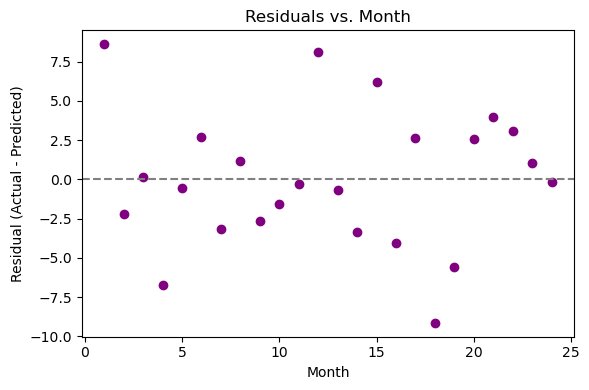

In [16]:
# Residual analysis
residuals = y - y_pred
 
# Plot residuals over time
plt.figure(figsize=(6, 4))
plt.scatter(df['Month'], residuals, color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Residuals vs. Month')
plt.xlabel('Month')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

### Residual Analysis
 
- The residuals appear randomly scattered around zero, which suggests that the model does not systematically over- or under-predict sales.
- This supports the assumption of linearity and constant variance (homoscedasticity).

### Summary
 
The linear regression model demonstrates a strong fit, with an R² value indicating that a significant portion of the variance in sales revenue is explained by advertising spend. The residuals are randomly scattered around zero, suggesting that the model does not systematically over- or under-predict, and that the assumptions of linearity and constant variance are reasonably satisfied. These results support the model’s reliability within the observed data range.

However, it’s important to recognize that this reliability may be misleading. As discussed earlier, the dataset is limited in scope—only 24 monthly observations and a single predictor variable. This narrow focus can introduce bias into the analysis. It’s similar to evaluating the quality of an entire basket of apples by only inspecting the freshest ones: by excluding other deliveries, we risk drawing incomplete or overly optimistic conclusions. Likewise, by modeling sales as a function of advertising spend alone, we overlook other influential factors such as seasonality, pricing, promotions, or market conditions. This simplification may lead to uninformed decisions when planning future investments, as the model does not account for the full complexity of real-world sales dynamics.

## Correlation vs. Causation
 
While the linear regression model shows a strong correlation between advertising spend and sales revenue, it is important to emphasize that correlation does not imply causation.
 
In this project, we observe that higher advertising spend is associated with higher sales. However, this does not prove that increased advertising directly causes the increase in sales. There may be other factors influencing both variables simultaneously.
 
### Examples of Possible Confounding Factors:
- **Seasonality**: Sales may naturally increase during certain months (e.g., holidays), and advertising budgets may also rise during those periods. The model might falsely attribute the sales increase solely to advertising.
- **Promotions or Product Launches**: If new products or discounts are introduced alongside increased advertising, the sales boost may be due to those factors rather than the ads themselves.
- **Economic Conditions**: A general improvement in the economy could lead to both higher advertising budgets and increased consumer spending.
 
### Directionality Issues:
It’s also possible that higher sales enable larger advertising budgets in future months, rather than advertising driving sales. This reverse relationship cannot be ruled out with the current data.
 
### Conclusion:
The model captures a statistical relationship, but not a causal one. To establish causation, controlled experiments (e.g., A/B testing) or more complex models with additional variables would be needed. For now, the results should be interpreted as indicative, not definitive.


## Final Project Summary
 
This project explored the relationship between advertising spend and sales revenue using a simple linear regression model based on 24 months of synthetic data. The goal was to understand whether advertising investment could be used to predict sales performance and to evaluate the reliability and limitations of such a model.
 
### Key Findings:
 
- The model demonstrated a strong fit, with an R² value indicating that a large portion of the variance in sales revenue is explained by advertising spend. The residuals were randomly scattered around zero, supporting the assumptions of linearity and constant variance.
 
- However, the dataset itself is limited: it contains only 24 monthly observations and includes just one predictor variable. This small and narrow sample increases the risk of overfitting and omits other important factors that influence sales, such as seasonality, promotions, or economic conditions.
 
- A simulation of Year 3 with reduced advertising effectiveness revealed a significant drop in model performance, illustrating the concept of model drift. This showed that the model’s predictive power can deteriorate over time if the underlying relationship between advertising and sales changes.
 
- The project also emphasized the distinction between correlation and causation. While the model found a strong statistical relationship, it cannot confirm that advertising directly causes sales to increase. Other confounding factors or reverse causality may be at play.
 
### Conclusion:
 
The project successfully demonstrates how linear regression can be used to model business relationships, but also highlights the importance of critical thinking in data analysis. A strong model fit does not guarantee reliability, especially when working with limited data or when key variables are excluded. To make informed decisions, it is essential to continuously monitor model performance, consider potential data drift, and avoid overinterpreting correlations as causal effects.
 
This project serves as a foundational example of data modeling and provides a platform for future enhancements, such as incorporating additional predictors, more variables that may influence the analyses (both internal and external) and testing for seasonality.